In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Astronomy / cosmology
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord


# Cosmology / large-scale structure
import pyccl as ccl

# MCMC
import emcee
import clevar
from clevar.catalog import ClCatalog, MemCatalog
from clevar.match_metrics import recovery
import matplotlib.pyplot as plt
from clevar.match import MembershipMatch
from clevar.match_metrics import distances
from clevar.match_metrics import scaling
from clevar.match import ProximityMatch
from clevar.match_metrics.recovery import ClCatalogFuncs as r_cf


# Miscentering Analysis

In [2]:
cat1_tags = {
    # identifiers
    "id": "cat1_id",
    "central_id": "cat1_id_cg",

    # redshift
    "redshift": "cat1_ztrue_cg",
    "redshift_true_central": "cat1_ztrue_cg",

    # sky position
    "ra": "cat1_ra",
    "dec": "cat1_dec",

    # richness
    "richness": "cat1_richness",
    "richness_err": "cat1_richness_err",

    # central galaxy probability
    "p_central_0": "cat1_p_cg_0",

    # matching metrics
    "mt_self": "cat1_mt_self",
    "mt_other": "cat1_mt_other",
    "mt_multi_self": "cat1_mt_multi_self",
    "mt_multi_other": "cat1_mt_multi_other",
    "mt_frac_self": "cat1_mt_frac_self",
    "mt_frac_other": "cat1_mt_frac_other",
    "mt_cross": "cat1_mt_cross",
    "mt_frac": "cat1_mt_frac",
}


In [3]:
cat2_tags = {
    # identifiers
    "id": "cat2_id",
    "skysim_halo_id": "cat2_skysim_halo_id",

    # redshift
    "redshift": "cat2_z",

    # sky position
    "ra": "cat2_ra",
    "dec": "cat2_dec",

    # masses
    "mass_fof": "cat2_mass_fof",
    "M200c": "cat2_M200c",

    # matching metrics
    "mt_self": "cat2_mt_self",
    "mt_other": "cat2_mt_other",
    "mt_multi_self": "cat2_mt_multi_self",
    "mt_multi_other": "cat2_mt_multi_other",
    "mt_frac_self": "cat2_mt_frac_self",
    "mt_frac_other": "cat2_mt_frac_other",
    "mt_cross": "cat2_mt_cross",
    "mt_frac": "cat2_mt_frac",
}


In [4]:
from astropy.table import Table
path_to_data = '/sps/lsst/users/ebarroso/CLCosmo_Sim_database/data/'
cat_data = Table.read(path_to_data + "matched_pairs_Mfofcut.fits")
cat_data = cat_data[(cat_data["cat2_z"] <= 1.0) & (cat_data["cat2_z"] >= 0.2)]
cat_data = cat_data[cat_data["cat2_M200c"] >= 4e13]
cat_data = cat_data[cat_data["cat1_richness"] >= 20]

Angular separation: min=0.0, max=0.05593954305777304
Max R_off [Mpc]: 1.0382
Mean R_off [Mpc]: 0.0333
Median R_off [Mpc]: 0.0000


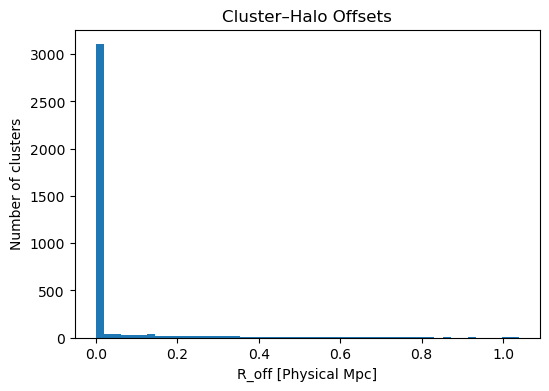

There is 0.1399498187900753% miscentered clusters


In [5]:
from tqdm import tqdm
cat_cl = ClCatalog('Cluster', data=cat_data, tags=cat1_tags)
cat_halo = ClCatalog('halos', data=cat_data, tags=cat2_tags)

cat_cl._add_skycoord()
cat_halo._add_skycoord()

mt = MembershipMatch()
ang_sep = mt._get_dist_mt(cat_cl, cat_halo, "angular_proximity")  

print(f"Angular separation: min={np.min(ang_sep)}, max={np.max(ang_sep)}")

ang_sep_rad = np.deg2rad(ang_sep)

h = 0.71
Omega_c = 0.1109 / h**2     # 0.2198
Omega_b = 0.02258 / h**2    # 0.0448

cosmo_dc2 = ccl.Cosmology(
    Omega_c = Omega_c,
    Omega_b = Omega_b,
    h       = h,
    sigma8  = 0.8,
    n_s     = 0.963,
    m_nu    = 0.0,
    w0      = -1.0,
    wa      = 0.0
)

cosmo = clevar.cosmology.CCLCosmology(be_cosmo = cosmo_dc2)
#cosmo = clevar.cosmology.AstroPyCosmology()
R_off = cosmo.rad2mpc(ang_sep_rad, cat_halo['redshift'])

# Step 5 — Add to your table
cat_data['R_off'] = R_off

# Step 6 — Diagnostics
print(f"Max R_off [Mpc]: {np.max(R_off):.4f}")
print(f"Mean R_off [Mpc]: {np.mean(R_off):.4f}")
print(f"Median R_off [Mpc]: {np.median(R_off):.4f}")

# Step 7 — Histogram
plt.figure(figsize=(6,4))
plt.hist(R_off, bins=50)
plt.xlabel("R_off [Physical Mpc]")
plt.ylabel("Number of clusters")
plt.title("Cluster–Halo Offsets")
plt.show()
frac_miscentering =  1.0 - len(R_off[R_off == 0.0]) / len(R_off)
print(f"There is {frac_miscentering}% miscentered clusters")

## Miscentering Gamma Function Fit

MCMC progress: 100%|██████████| 10000/10000 [00:45<00:00, 220.85it/s]


Sigma offset: 0.119 +0.004 -0.004 Mpc


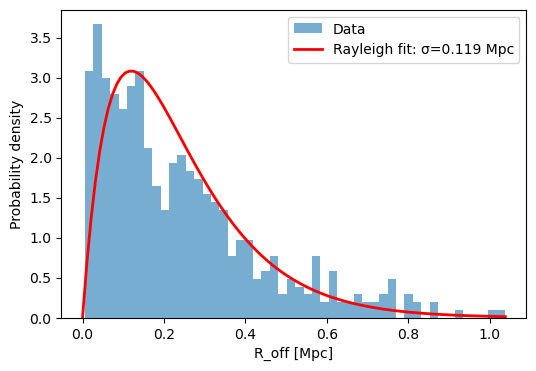

The paper offset is: 0.001449


In [6]:
from tqdm import tqdm
r_off = cat_data['R_off']
R = r_off[r_off != 0.0]
def log_likelihood(theta, R):
    sigma = theta[0]
    if sigma <= 0:
        return -np.inf
    return np.sum(np.log(R / sigma**2) - R / sigma)

def log_prior(theta):
    sigma = theta[0]
    if 0 < sigma < 5.0:  # Mpc
        return 0.0
    return -np.inf

def log_posterior(theta, R):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, R)

# MCMC setup
ndim = 1  # only sigma
nwalkers = 32
nsteps = 10000
initial = 0.2 + 0.01 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(R,))

samples_list = []
with tqdm(total=nsteps, desc="MCMC progress") as pbar:
    for sample in sampler.sample(initial, iterations=nsteps, progress=False):
        pbar.update(1)
    samples_list.append(sampler.get_chain())

samples = sampler.get_chain(discard=1000, flat=True)
sigma_mcmc = np.percentile(samples[:,0], [16, 50, 84])
print(f"Sigma offset: {sigma_mcmc[1]:.3f} +{sigma_mcmc[2]-sigma_mcmc[1]:.3f} -{sigma_mcmc[1]-sigma_mcmc[0]:.3f} Mpc")

sigma_best = sigma_mcmc[1]
R_plot = np.linspace(0, np.max(R), 100)
pdf = (R_plot / sigma_best**2) * np.exp(-R_plot / sigma_best)

plt.figure(figsize=(6,4))
plt.hist(R, bins=50, density=True, alpha=0.6, label="Data")
plt.plot(R_plot, pdf, 'r-', lw=2, label=f"Rayleigh fit: σ={sigma_best:.3f} Mpc")
plt.xlabel("R_off [Mpc]")
plt.ylabel("Probability density")
plt.legend()
plt.show()
cosmodc2_paper =  0.03 * (1.07*0.04 + 0.19 * 0.03 - 0.02*0.01 )
print(f"The paper offset is: {cosmodc2_paper}")



## Miscentering Effect On Delta Sigma

In [7]:
from crow import ClusterShearProfile
### Cluster Delta Sigma Modeling with and no msicentering ###
cosmo = ccl.Cosmology(
    Omega_c=0.1109 / 0.71**2,
    Omega_b=0.02258 / 0.71**2,
    h=0.71,
    n_s=0.963,
    sigma8=0.8,
    w0=-1.0,
    wa=0.0,
    transfer_function="boltzmann_camb"
)

hmf = ccl.halos.MassFuncDespali16(mass_def="200c")
cluster_ds = ClusterShearProfile(cosmo, hmf, is_delta_sigma=True, cluster_concentration=4.0)

cluster_ds_mis = ClusterShearProfile(cosmo, hmf, is_delta_sigma=True, cluster_concentration=4.0)

cluster_ds_mis.set_miscentering(frac_miscentering , sigma_best)

mass_interval = np.linspace(13., 15., 4)
z_interval = np.array([0.5, 0.5, 0.5, 0.5])
radius_centers = np.array([1.0, 2.0, 3.0])

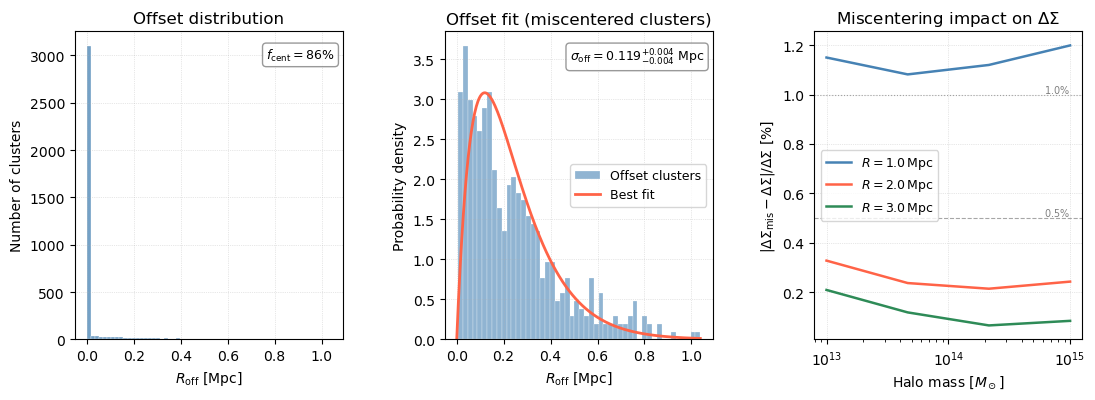

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Color cycle for the three radii
colors = ["steelblue", "tomato", "seagreen"]

r_off     = cat_data['R_off']
R_nonzero = r_off[r_off != 0.0]

sigma_best = sigma_mcmc[1]
sigma_lo   = sigma_mcmc[1] - sigma_mcmc[0]
sigma_hi   = sigma_mcmc[2] - sigma_mcmc[1]

R_plot       = np.linspace(0, np.max(R_nonzero), 300)
pdf_fit      = (R_plot / sigma_best**2) * np.exp(-R_plot / sigma_best)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.subplots_adjust(wspace=0.38)

# ── Left panel: full offset histogram ────────────────────────────────────────
ax0 = axes[0]
ax0.hist(r_off, bins=60, color="steelblue", alpha=0.75,
         edgecolor="white", linewidth=0.3)
frac_zero = np.mean(r_off == 0.0) * 100
#ax0.axvline(0, color="k", lw=0.8, ls="--", alpha=0.4)
ax0.set_xlabel(r"$R_\mathrm{off}\ [\mathrm{Mpc}]$")
ax0.set_ylabel("Number of clusters")
ax0.set_title("Offset distribution")
ax0.text(0.97, 0.95,
         fr"$f_\mathrm{{cent}} = {frac_zero:.0f}\%$",
         transform=ax0.transAxes, fontsize=9, ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
ax0.grid(True, ls=":", lw=0.5, alpha=0.6)

# ── Center panel: fit to non-zero offsets ─────────────────────────────────
ax1 = axes[1]
ax1.hist(R_nonzero, bins=50, density=True, color="steelblue",
         alpha=0.6, edgecolor="white", linewidth=0.3, label="Offset clusters")
ax1.plot(R_plot, pdf_fit, color="tomato", lw=2, label="Best fit")
# sigma annotation inside the plot, no need to clutter the legend
ax1.text(0.97, 0.95,
         fr"$\sigma_\mathrm{{off}} = {sigma_best:.3f}"
         fr"^{{+{sigma_hi:.3f}}}_{{-{sigma_lo:.3f}}}\ \mathrm{{Mpc}}$",
         transform=ax1.transAxes, fontsize=9, ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
ax1.set_xlabel(r"$R_\mathrm{off}\ [\mathrm{Mpc}]$")
ax1.set_ylabel("Probability density")
ax1.set_title("Offset fit (miscentered clusters)")
ax1.legend(fontsize=9, framealpha=0.8)
ax1.grid(True, ls=":", lw=0.5, alpha=0.6)

# ── Right panel: % difference only ───────────────────────────────────────────
ax2 = axes[2]

for color, radius_center in zip(colors, radius_centers):
    shear_centered    = cluster_ds.compute_shear_profile(
                            mass_interval, z_interval, radius_center)
    shear_miscentered = cluster_ds_mis.compute_shear_profile(
                            mass_interval, z_interval, radius_center)
    mass     = 10**mass_interval
    pct_diff = 100 * np.abs(shear_miscentered - shear_centered) / shear_centered

    ax2.plot(mass, pct_diff, color=color, lw=1.8,
             label=fr"$R = {radius_center}\,\mathrm{{Mpc}}$")

# Reference lines at 0.5% and 1%
for level, ls in zip([0.5, 1.0], ["--", ":"]):
    ax2.axhline(level, color="gray", lw=0.8, ls=ls, alpha=0.7)
    ax2.text(mass[-1], level, fr"${level}\%$",
             fontsize=7, color="gray", va="bottom", ha="right")

ax2.set_xscale("log")
ax2.set_xlabel(r"Halo mass $[M_\odot]$")
ax2.set_ylabel(r"$|\Delta\Sigma_\mathrm{mis} - \Delta\Sigma| / \Delta\Sigma\ [\%]$")
ax2.set_title(r"Miscentering impact on $\Delta\Sigma$")
ax2.legend(fontsize=9, framealpha=0.8)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax2.grid(True, ls=":", lw=0.5, alpha=0.6)

fig.savefig("./figures/miscentering.pdf", bbox_inches="tight", dpi=150)
plt.show()